# 02 — Preprocessing

Filter low-count genes and compute DESeq2-style median-of-ratios size factors.

In [1]:
import sys
sys.path.insert(0, '../src')

from rnaseq.io import load_dataset
from rnaseq.config import PipelineConfig
from rnaseq.preprocessing import run_preprocessing

dataset = load_dataset('../data/example_dataset/counts.csv', '../data/example_dataset/metadata.csv', condition_column='condition')
config = PipelineConfig(counts_path='x', metadata_path='y')

In [2]:
result = run_preprocessing(dataset.counts, config)
print(f'Removed {result.n_genes_removed} low-count genes')
result.size_factors

Removed 17 low-count genes


control_1    1.077600
control_2    1.188595
control_3    1.045747
control_4    0.983317
stress_1     1.034641
stress_2     0.996678
stress_3     0.913275
stress_4     1.007911
dtype: float64

Size factors correct for sequencing-depth differences between samples before any downstream comparison.

/tmp/ipykernel_791/1171595781.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(log_before.values, labels=log_before.columns, showfliers=False)
/tmp/ipykernel_791/1171595781.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(log_after.values, labels=log_after.columns, showfliers=False)


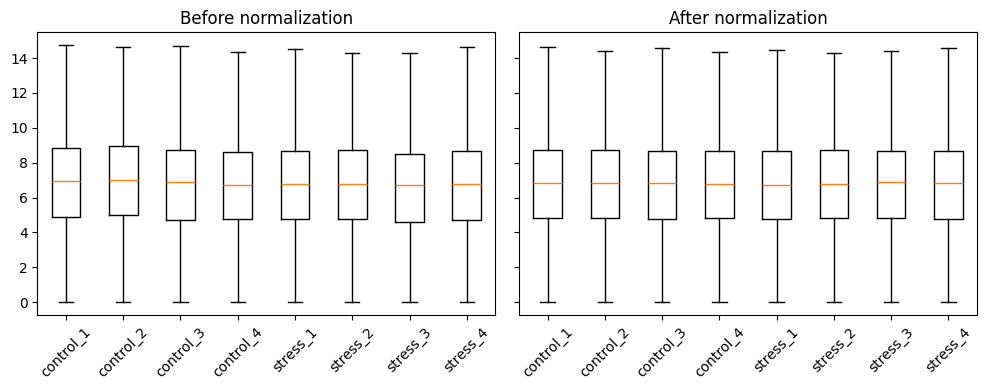

In [3]:
import numpy as np
import matplotlib.pyplot as plt

log_before = np.log2(dataset.counts + 1)
log_after = np.log2(result.normalized_counts + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].boxplot(log_before.values, labels=log_before.columns, showfliers=False)
axes[0].set_title('Before normalization')
axes[1].boxplot(log_after.values, labels=log_after.columns, showfliers=False)
axes[1].set_title('After normalization')
for ax in axes: ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()